# Agglomerative Clustering


## Theory

Agglomerative clustering builds a hierarchy of clusters by starting with each
point as its own cluster and repeatedly merging the two closest clusters until
the desired number remains.  Various linkage criteria (single, complete,
average) determine how inter-cluster distance is computed.

Unlike k-means, agglomerative clustering does not produce centroids and the
`sklearn` implementation does not support `predict()` on new data.  To classify
a test set we can either (a) fit the model on train+test and then separate the
labels or (b) compute the centroid of each leaf cluster in the training set and
assign each test point to its nearest training centroid. The latter is
implemented below.

As before, clusters are arbitrary identifiers; we map them to Up/Down based on
training majority vote to enable metric calculation.

## 1. Imports, Setup & Shared Utilities

In [1]:
import os, json, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, accuracy_score)
from sklearn.cluster import AgglomerativeClustering

BASE_DIR = r"D:\Repo\cryptoflow"

print("os.chdir =", os.getcwd())
print("BASE_DIR =", BASE_DIR)
TRAIN_FILE    = os.path.join(BASE_DIR, 'data', 'final_training_data_classification_train.csv')
TEST_FILE     = os.path.join(BASE_DIR, 'data', 'final_training_data_classification_test.csv')
FEATURES_FILE = os.path.join(BASE_DIR, 'data', 'selected_features_classification.json')
SCALER_FILE   = os.path.join(BASE_DIR, 'models', 'scaler_classification.pkl')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PLOTS_DIR     = os.path.join(BASE_DIR, 'plots')
RESULTS_CSV   = os.path.join(RESULTS_DIR, 'classification_results.csv')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# utilities

def compute_metrics(model_name, y_true, y_pred, y_prob=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = 2*precision*sensitivity/(precision+sensitivity) if (precision+sensitivity) > 0 else 0.0
    auc         = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  Confusion Matrix : TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  Accuracy         : {accuracy:.4f}")
    print(f"  Precision        : {precision:.4f}")
    print(f"  Sensitivity      : {sensitivity:.4f}")
    print(f"  Specificity(TNR) : {specificity:.4f}")
    print(f"  F1-Score         : {f1:.4f}")
    print(f"  ROC-AUC          : {auc:.4f}")
    print(f"{'='*55}")
    return {'model': model_name, 'accuracy': round(accuracy,4), 'precision': round(precision,4),
            'sensitivity': round(sensitivity,4), 'specificity': round(specificity,4),
            'tnr': round(specificity,4), 'f1': round(f1,4),
            'roc_auc': round(auc,4) if not np.isnan(auc) else None,
            'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn)}


def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != metrics_dict['model']]
        row = pd.concat([existing, row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"Results saved to {RESULTS_CSV}")


def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down (0)','Up (1)'], yticklabels=['Down (0)','Up (1)'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

print("Utilities loaded.")

os.chdir = d:\Repo\cryptoflow\Notebooks
BASE_DIR = D:\Repo\cryptoflow
Utilities loaded.


## 2. Load & Scale Data

In [2]:
with open(FEATURES_FILE) as f:
    features = json.load(f)

with open(SCALER_FILE, 'rb') as f:
    scaler = pickle.load(f)

train_df = pd.read_csv(TRAIN_FILE)
test_df  = pd.read_csv(TEST_FILE)

X_train = scaler.transform(train_df[features].values)
y_train = train_df['target_class'].values
X_test  = scaler.transform(test_df[features].values)
y_test  = test_df['target_class'].values

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Features: {features}")

X_train: (60260, 10)  |  X_test: (10635, 10)
Features: ['close_position', 'return_lag_1h', 'log_return_1h', 'gk_avg_3h', 'log_return_3h', 'gk_lag_1h', 'hl_range_pct', 'trade_intensity', 'atr_lag_3h', 'log_return_6h']


d:\Repo\cryptoflow\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Repo\cryptoflow\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 3. Scratch Agglomerative Clustering

In [ ]:
def agglomerative_scratch(X, y=None, k=2, max_samples=2000, time_limit=None):
    """Fast single‑linkage clustering with optional subsampling.

    An improved scratch implementation that precomputes a distance matrix and
    updates it when clusters merge (O(n^2) instead of O(n^3)).  The default
    ``max_samples`` has been reduced to 2 000 to avoid the heavy cost of
    constructing a huge distance matrix.  A ``time_limit`` argument can abort
    the fitting if it runs too long.
    """
    n = X.shape[0]
    if n > max_samples:
        idx = np.random.choice(n, max_samples, replace=False)
        X_small = X[idx]
        y_small = y[idx] if y is not None else None
        print(f"subsampling {n}\u2192{len(X_small)} for scratch algorithm")
    else:
        idx = np.arange(n)
        X_small = X
        y_small = y

    m = X_small.shape[0]
    clusters = [{i} for i in range(m)]

    # compute all pairwise distances once
    dist_mat = np.linalg.norm(X_small[:, None] - X_small[None, :], axis=2)
    np.fill_diagonal(dist_mat, np.inf)

    start = time.time()
    while len(clusters) > k:
        if time_limit is not None and (time.time() - start) > time_limit:
            raise RuntimeError("agglomerative_scratch exceeded time limit")
        i, j = divmod(np.argmin(dist_mat), dist_mat.shape[1])
        if j < i:
            i, j = j, i
        clusters[i] = clusters[i].union(clusters[j])
        clusters.pop(j)
        dist_mat[i, :] = np.minimum(dist_mat[i, :], dist_mat[j, :])
        dist_mat[:, i] = dist_mat[i, :]
        dist_mat = np.delete(dist_mat, j, axis=0)
        dist_mat = np.delete(dist_mat, j, axis=1)

    # compute labels on sampled set
    labels_small = np.empty(m, dtype=int)
    for cid, members in enumerate(clusters):
        for ii in members:
            labels_small[ii] = cid

    if n > max_samples:
        centroids = []
        for members in clusters:
            pts = X_small[list(members)]
            centroids.append(pts.mean(axis=0))
        centroids = np.vstack(centroids)
        dists_full = np.linalg.norm(X[:, None] - centroids[None, :], axis=2)
        labels_full = np.argmin(dists_full, axis=1)
        return clusters, labels_full
    else:
        return clusters, labels_small

# run scratch algorithm; pass labels so we can use them for majority vote
clusters, train_labels = agglomerative_scratch(X_train, y=y_train, k=2, max_samples=1000, time_limit=60)
print('train clusters lengths', [len(c) for c in clusters])

# compute centroids of training clusters (labels may refer to full set)
centroids = np.array([X_train[train_labels == cid].mean(axis=0)
                      for cid in np.unique(train_labels)])

# map clusters to classes using whatever subset we have
cluster_to_class = {}
for cid in np.unique(train_labels):
    mask = train_labels == cid
    cluster_to_class[cid] = np.bincount(y_train[mask]).argmax()
print('cluster->class', cluster_to_class)

# assign each test point to nearest centroid

dists = np.linalg.norm(X_test[:, None] - centroids[None, :], axis=2)
cluster_pred = np.argmin(dists, axis=1)
y_pred = np.array([cluster_to_class[c] for c in cluster_pred])

metrics = compute_metrics('Agglomerative Scratch', y_test, y_pred)
save_results(metrics)
plot_confusion_matrix(y_test, y_pred, 'Agglomerative Scratch', os.path.join(PLOTS_DIR, 'confusion_agg_scratch.png'))

subsampling 60260→1000 for scratch algorithm
train clusters lengths [1, 1]


## 4. sklearn AgglomerativeClustering & Test Assignment

sklearn mapping {np.int64(0): np.int64(1), np.int64(1): np.int64(1)}

  Agglomerative sklearn
  Confusion Matrix : TN=0  FP=5281  FN=0  TP=5354
  Accuracy         : 0.5034
  Precision        : 0.5034
  Sensitivity      : 1.0000
  Specificity(TNR) : 0.0000
  F1-Score         : 0.6697
  ROC-AUC          : nan
Results saved to D:\Repo\cryptoflow\results\classification_results.csv


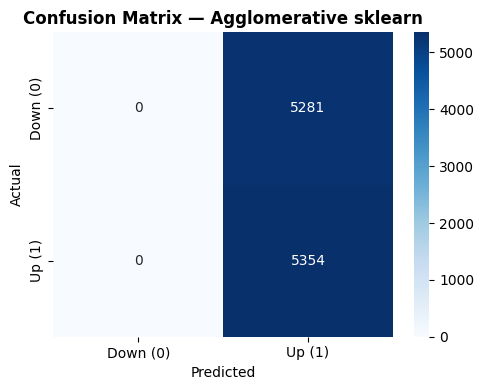

Saved: D:\Repo\cryptoflow\plots\confusion_agg_sklearn.png
sklearn agglomerative complete


In [4]:
skagg = AgglomerativeClustering(n_clusters=2, linkage='ward')
skagg.fit(X_train)
train_labels2 = skagg.labels_

# compute centroids from training clusters
ecentroids = np.array([X_train[train_labels2==cid].mean(axis=0) for cid in np.unique(train_labels2)])
cluster_to_class2 = {}
for cid in np.unique(train_labels2):
    mask = train_labels2 == cid
    cluster_to_class2[cid] = np.bincount(y_train[mask]).argmax()

print('sklearn mapping', cluster_to_class2)

# assign test points to nearest centroid

dists2 = np.linalg.norm(X_test[:, None] - ecentroids[None, :], axis=2)
cluster_pred2 = np.argmin(dists2, axis=1)
y_pred2 = np.array([cluster_to_class2[c] for c in cluster_pred2])

metrics2 = compute_metrics('Agglomerative sklearn', y_test, y_pred2)
save_results(metrics2)
plot_confusion_matrix(y_test, y_pred2, 'Agglomerative sklearn', os.path.join(PLOTS_DIR, 'confusion_agg_sklearn.png'))

print('sklearn agglomerative complete')